# Sentiment Trajectories

**Navigation**: [← Previous: Corpus & Cleaning](01_corpus.ipynb) | [Next: Emotion Lexicon →](03_emotions.ipynb)

VADER compound scores along each novel — a rolling mood line from first page to last.


## Method

[VADER](https://github.com/cjhutto/vaderSentiment) (Valence Aware Dictionary and sEntiment Reasoner) assigns each page a **compound** score in $[-1, 1]$: below 0 leans negative, above 0 leans positive. We then take a centred rolling mean (8 pages) so a single melodramatic paragraph does not dominate.

The x-axis is **progress through the book** (0–100%), not raw page number, so *Alice* and *Dracula* can be drawn on the same chart.

In [1]:

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJ_DIR = Path('.').resolve()
if not (PROJ_DIR / 'gutenberg_utils.py').exists():
    PROJ_DIR = Path('projects/literary-nlp').resolve()
if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

from gutenberg_utils import (
    load_pages, book_catalog, title_of, BOOK_COLORS, BOOKS,
    THEMATIC_KEYWORDS, all_stopwords, ensure_nltk_data,
    add_vader_sentiment, add_nrc_emotions, NRC_EMOTIONS,
    keyword_counts, character_mentions, third_label,
)

def display_plotly(fig):
    """Embed Plotly with CDN JS — fig.show() is blank in Jupyter Book HTML."""
    display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

PAGES = load_pages()
CATALOG = book_catalog()
print(f"Loaded {len(PAGES):,} pages across {PAGES['book_id'].nunique()} books")


Loaded 2,653 pages across 8 books


In [2]:
ensure_nltk_data()
scored = add_vader_sentiment(PAGES)
print(scored.groupby('title')['compound'].agg(['mean', 'std', 'min', 'max']).round(3))


                                   mean    std    min    max
title                                                       
A Christmas Carol                 0.387  0.780 -0.993  0.997
Alice's Adventures in Wonderland  0.105  0.813 -0.989  0.991
Dracula                           0.220  0.804 -0.995  0.998
Frankenstein                      0.092  0.895 -0.998  0.997
Pride and Prejudice               0.644  0.616 -0.987  0.998
The Picture of Dorian Gray        0.298  0.807 -0.996  0.998
The Time Machine                  0.114  0.811 -0.994  0.992
Wuthering Heights                -0.115  0.847 -0.996  0.997


## Overlay: eight novels, one axis

In [3]:
fig = go.Figure()
for book_id, grp in scored.groupby('book_id', sort=False):
    fig.add_trace(go.Scatter(
        x=grp['progress'] * 100,
        y=grp['compound_smooth'],
        mode='lines',
        name=title_of(book_id),
        line=dict(color=BOOK_COLORS[book_id], width=2),
        hovertemplate='%{x:.0f}% progress<br>sentiment %{y:.2f}<extra>' + title_of(book_id) + '</extra>',
    ))
fig.update_layout(
    title='Smoothed VADER sentiment vs progress',
    xaxis_title='Progress through the book (%)',
    yaxis_title='Compound sentiment (rolling mean)',
    template='plotly_white',
    height=520,
    legend=dict(orientation='h', y=-0.2),
    shapes=[dict(type='line', x0=0, x1=100, y0=0, y1=0,
                 line=dict(color='gray', width=1, dash='dot'))],
)
display_plotly(fig)


Static copy for the project landing page:

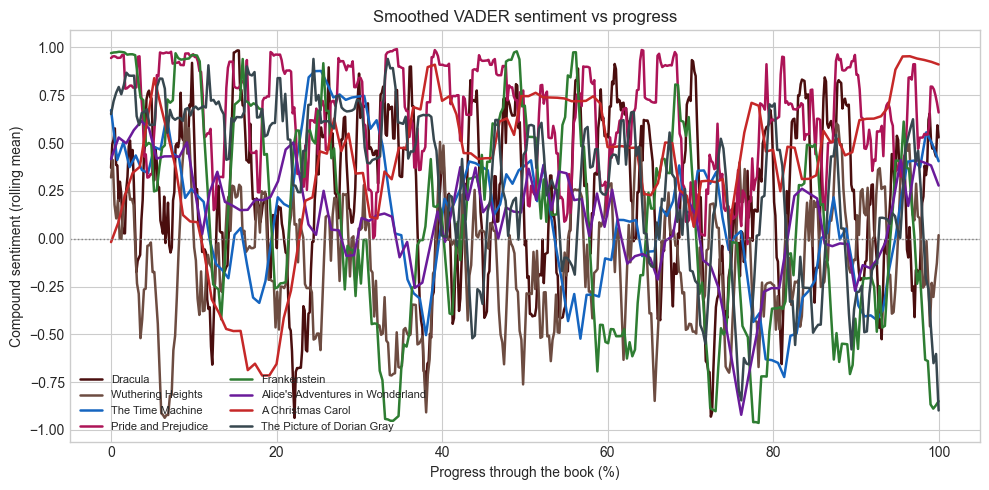

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
for book_id, grp in scored.groupby('book_id', sort=False):
    ax.plot(grp['progress'] * 100, grp['compound_smooth'],
            color=BOOK_COLORS[book_id], label=title_of(book_id), linewidth=1.8)
ax.axhline(0, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Progress through the book (%)')
ax.set_ylabel('Compound sentiment (rolling mean)')
ax.set_title('Smoothed VADER sentiment vs progress')
ax.legend(loc='lower left', fontsize=8, ncol=2)
plt.tight_layout()
fig.savefig(PROJ_DIR / 'figures' / '02_sentiment_overlay.png', dpi=120)
plt.show()


## One panel per book

In [5]:
facet = scored.copy()
facet['Progress (%)'] = facet['progress'] * 100
fig = px.line(
    facet, x='Progress (%)', y='compound_smooth', color='title', facet_col='title',
    facet_col_wrap=2, color_discrete_map={title_of(k): v for k, v in BOOK_COLORS.items()},
    labels={'compound_smooth': 'Sentiment'},
)
fig.update_layout(template='plotly_white', height=900, showlegend=False,
                  title='Sentiment trajectory by novel')
fig.update_yaxes(matches=None)
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))
display_plotly(fig)


## Does the ending darken?

Mean compound score in the first third versus the last third. A negative delta means the close is darker than the opening.

In [6]:
ends = scored.copy()
ends['third'] = third_label(ends['progress'])
pivot = (
    ends.groupby(['title', 'third'], observed=True)['compound'].mean()
    .unstack('third')[['beginning', 'end']]
)
pivot['delta (end − start)'] = pivot['end'] - pivot['beginning']
pivot['arc'] = np.where(pivot['delta (end − start)'] < -0.02, 'darkens',
                        np.where(pivot['delta (end − start)'] > 0.02, 'brightens', 'flat'))
pivot.round(3).sort_values('delta (end − start)')


third,beginning,end,delta (end − start),arc
title,,,,
The Picture of Dorian Gray,0.652,-0.046,-0.698,darkens
Frankenstein,0.380,-0.186,-0.566,darkens
The Time Machine,0.385,-0.043,-0.428,darkens
Alice's Adventures in Wonderland,0.284,-0.022,-0.305,darkens
Pride and Prejudice,0.709,0.540,-0.169,darkens
Dracula,0.247,0.187,-0.060,darkens
Wuthering Heights,-0.101,-0.059,0.042,brightens
A Christmas Carol,0.050,0.519,0.469,brightens


## How to read the arcs

- **A Christmas Carol** is the control case: five staves from miserliness to generosity, so the line should rise.
- **Pride and Prejudice** stays relatively warm — social friction, not gothic dread.
- **Alice** is playful; dips are more likely nonsense-court tension than tragedy.
- **Dracula**, **Frankenstein**, and **Dorian Gray** are the titles we expect to finish darker than they begin. VADER may still score a triumphant vampire-hunt ending as “positive” because of words like *win*, *light*, and *god*. That is a feature of the lexicon, not a plot spoiler.

---

**Navigation**: [← Previous: Corpus & Cleaning](01_corpus.ipynb) | [Next: Emotion Lexicon →](03_emotions.ipynb)
